# Table of Contents

1. [Load Data](#load-data)
2. [Data Cleaning and Feature engineering](#data-cleaning-and-feature-engineering)
3. [Dimentionality Reduction](#dimentionality-reduction)
4. [Silhouette and Elbow Visualization](#silhouette-and-elbow-visualization)
5. [Imported Cluster Labels](#imported-cluster-labels)
6. [Result Analysis & Visualizations](#result-analysis--visualizations)

## Note, Please follow this order to run the files:
### 1. Run 1. to 4. first. 
### 2. Then run the Rmarkdown file. (Version_A_Selective_Inference.Rmd)
### 3. Run 5. and 6. for visualization and final labels.

## Load Data

In [85]:
import pandas as pd
from pathlib import Path

csv_path = "../Clustering/clustering_Cleaned.csv"
df_full = pd.read_csv(csv_path)

# Drop specified columns
cols_to_drop = [
    'card_transaction_count',
    'Credit_Amount_Total',
    'Debit_Amount_Total',
]
cols_to_drop = [col for col in cols_to_drop if col in df_full.columns]
if cols_to_drop:
    df_full = df_full.drop(columns=cols_to_drop)
    print(f"Dropped columns: {cols_to_drop}")
else:
    print("No specified columns found to drop")

# Filter for business only
df = df_full[df_full['kyc_type'].str.lower() == 'business'].copy()
print(f"Full dataset: {len(df_full)} rows")
print(f"Filtered to business customers only: {len(df)} rows")

df.head()
df.isna().sum()

Dropped columns: ['card_transaction_count', 'Credit_Amount_Total', 'Debit_Amount_Total']
Full dataset: 61410 rows
Filtered to business customers only: 8311 rows


C:\Users\houju\AppData\Local\Temp\ipykernel_44380\663868764.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv(csv_path)


customer_id                                0
kyc_type                                   0
province                                   0
city                                       0
industry_code                             20
occupation_code                         8311
sales_cents                                0
account_age                              754
birth_business_age                       410
total_transaction_count                    0
transaction_count_ABM                      0
transaction_count_Card                     0
transaction_count_Cheque                   0
transaction_count_EFT                      0
transaction_count_EMT                      0
transaction_count_Western Union            0
transaction_count_Wire                     0
debit_transaction_count                  207
debit_transaction_amount                 207
credit_transaction_count                 425
credit_transaction_amount                425
average_debit_transaction_amount         207
average_cr

## Data Cleaning and Feature engineering

In [86]:
# Keep industry_code for business, drop occupation_code
import numpy as np

# Drop occupation_code (not needed for business)
df = df.drop(columns=["occupation_code"])

# Fill NA values in industry_code with mode
if 'industry_code' in df.columns:
    mode_value = df['industry_code'].mode()
    if len(mode_value) > 0:
        df['industry_code'] = df['industry_code'].fillna(mode_value[0])
        print(f"Filled NA values in 'industry_code' with mode: {mode_value[0]}")
    else:
        print("Warning: Could not find mode for 'industry_code' (all values may be NA)")

# Convert industry_code to categorical dtype (recommended for FAMD)
df["industry_code"] = df["industry_code"].astype("category")

# Quick sanity checks
print("industry_code nunique:", df["industry_code"].nunique())
print(df["industry_code"].value_counts().head(10))

Filled NA values in 'industry_code' with mode: Other
industry_code nunique: 169
industry_code
Other    1548
7215      661
7771      429
4561      344
7292      248
4013      232
8651      231
7761      173
7799      150
7721      133
Name: count, dtype: int64


In [87]:
# Replace industry_code values that appear less than 100 times with "Other"
if 'industry_code' in df.columns:
    # Count frequency of each industry_code
    industry_code_counts = df['industry_code'].value_counts()
    
    # Find industry_code values that appear less than 100 times (excluding NaN)
    rare_industry_codes = industry_code_counts[industry_code_counts < 100].index.tolist()
    
    print(f"Found {len(rare_industry_codes)} industry_code values appearing less than 100 times")
    
    # Create mask for rows with rare industry_code values
    rare_mask = df['industry_code'].isin(rare_industry_codes)
    print(f"Total rows to be changed: {rare_mask.sum()}")
    
    # Replace rare industry_code values with "Other"
    df.loc[rare_mask, 'industry_code'] = 'Other'
    
    # Drop unused category levels. Otherwise value_counts() can list 0-count levels and
    # FAMD still sees the old high-cardinality category set.
    if hasattr(df['industry_code'].dtype, 'categories'):
        df['industry_code'] = df['industry_code'].cat.remove_unused_categories()
    else:
        df['industry_code'] = df['industry_code'].astype('category')
    
    # Show updated distribution
    print(f"\nUpdated industry_code distribution:")
    print(df['industry_code'].value_counts().head(40))
else:
    print("Column 'industry_code' not found in dataframe")

Found 154 industry_code values appearing less than 100 times
Total rows to be changed: 3603

Updated industry_code distribution:
industry_code
Other    5151
7215      661
7771      429
4561      344
7292      248
4013      232
8651      231
7761      173
7799      150
7721      133
8653      123
8652      113
9211      112
9953      107
9861      104
Name: count, dtype: int64


In [88]:
# 2. account_age and birth_business_age: fill nulls with median
# Fill with median
df['account_age'] = df['account_age'].fillna(df['account_age'].median())
df['birth_business_age'] = df['birth_business_age'].fillna(df['birth_business_age'].median())

In [89]:
# 3. Fill debit and credit nulls to 0
debit_credit_cols = [
    'debit_transaction_count',
    'debit_transaction_amount',
    'average_debit_transaction_amount',
    'credit_transaction_count',
    'credit_transaction_amount',
    'average_credit_transaction_amount'
]

for col in debit_credit_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

In [90]:
# 4. Fill nulls in columns with prefix 'card_' or 'abm_' to 0
card_abm_cols = [col for col in df.columns if col.startswith('card_') or col.startswith('abm_')]
for col in card_abm_cols:
    if col == 'card_top_mcc':
        df[col] = df[col].fillna('N/A')
    elif col == 'card_second_mcc':
        df[col] = df[col].fillna('N/A')
    elif col=='card_ecommerce_to_nonecommerce_ratio':
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(0)

In [91]:
# 5. Replace MCC codes in card_top_mcc that appear less than 50 times with "other"
if 'card_top_mcc' in df.columns:
    # Count frequency of each MCC code
    mcc_counts = df['card_top_mcc'].value_counts()
    
    # Find MCC codes that appear less than 50 times (excluding N/A and null)
    rare_mccs = mcc_counts[mcc_counts < 50].index.tolist()
    
    # Exclude 'N/A' from being replaced
    if 'N/A' in rare_mccs:
        rare_mccs.remove('N/A')
    
    print(f"Found {len(rare_mccs)} MCC codes appearing less than 100 times")
    print(f"Total rows to be changed: {df['card_top_mcc'].isin(rare_mccs).sum()}")
    
    # Replace rare MCC codes with "other"
    df.loc[df['card_top_mcc'].isin(rare_mccs), 'card_top_mcc'] = 'other'
    
    # Show updated distribution
    print(f"\nUpdated card_top_mcc distribution:")
    print(df['card_top_mcc'].value_counts().head(40))
else:
    print("Column 'card_top_mcc' not found in dataframe")

Found 62 MCC codes appearing less than 100 times
Total rows to be changed: 493

Updated card_top_mcc distribution:
card_top_mcc
N/A      4234
0         865
other     759
5411      499
5814      460
5541      434
5542      336
5251      165
4816      154
5812      153
5310      109
5200       90
4121       53
Name: count, dtype: int64


In [92]:
# 6. Replace cities that appear less than 100 times with "other"
if 'city' in df.columns:
    # Count frequency of each city
    city_counts = df['city'].value_counts()
    
    # Find cities that appear less than 100 times (excluding N/A and null)
    rare_cities = city_counts[city_counts < 100].index.tolist()
    
    # Exclude 'N/A' from being replaced
    if 'N/A' in rare_cities:
        rare_cities.remove('N/A')
    
    print(f"Found {len(rare_cities)} cities appearing less than 100 times")
    print(f"Total rows to be changed: {df['city'].isin(rare_cities).sum()}")
    
    # Replace rare cities with "other"
    df.loc[df['city'].isin(rare_cities), 'city'] = 'other'
    
    # Show updated distribution
    print(f"\nUpdated city distribution:")
    print(df['city'].value_counts().head(40))
else:
    print("Column 'city' not found in dataframe")


Found 139 cities appearing less than 100 times
Total rows to be changed: 3073

Updated city distribution:
city
other          5988
TORONTO         562
CALGARY         368
EDMONTON        242
BRAMPTON        229
OTTAWA          181
MISSISSAUGA     159
VANCOUVER       142
SCARBOROUGH     122
WINNIPEG        108
SURREY          106
NORTH YORK      104
Name: count, dtype: int64


In [93]:
# 5. Remove customer_id and card_second_mcc, but KEEP sales_cents for business
if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])
if 'card_second_mcc' in df.columns:
    df = df.drop(columns=['card_second_mcc'])

# Drop transaction count columns for Western Union and Wire
if 'transaction_count_Western Union' in df.columns:
    df = df.drop(columns=['transaction_count_Western Union'])
if 'transaction_count_Wire' in df.columns:
    df = df.drop(columns=['transaction_count_Wire'])

# Drop ABM count columns
if 'abm_cash_count' in df.columns:
    df = df.drop(columns=['abm_cash_count'])
if 'abm_non_cash_count' in df.columns:
    df = df.drop(columns=['abm_non_cash_count'])

# Drop ABM transaction count columns
if 'abm_transaction_count' in df.columns:
    df = df.drop(columns=['abm_transaction_count'])
if 'transaction_count_ABM' in df.columns:
    df = df.drop(columns=['transaction_count_ABM'])

# Drop abm_cash_to_non_cash_ratio
if 'abm_cash_to_non_cash_ratio' in df.columns:
    df = df.drop(columns=['abm_cash_to_non_cash_ratio'])
    print("Dropped 'abm_cash_to_non_cash_ratio' column")

if "card_ecommerce_to_nonecommerce_ratio" in df.columns:
    df=df.drop(columns=['card_ecommerce_to_nonecommerce_ratio'])
    
# Note: sales_cents is kept for business analysis

# Handle the three new columns: Debit_Amount_Total, Credit_Amount_Total, Averagetime_between_alltransaction
# Rename Averagetime_between_alltransaction to Averagetime_between_transaction_day
if 'Averagetime_between_alltransaction' in df.columns:
    df = df.rename(columns={'Averagetime_between_alltransaction': 'Averagetime_between_transaction_day'})
    print("Renamed 'Averagetime_between_alltransaction' to 'Averagetime_between_transaction_day'")

# Fill Averagetime_between_transaction_day with median
if 'Averagetime_between_transaction_day' in df.columns:
    median_value = df['Averagetime_between_transaction_day'].median()
    df['Averagetime_between_transaction_day'] = df['Averagetime_between_transaction_day'].fillna(median_value)
    print(f"Filled null values in 'Averagetime_between_transaction_day' with median: {median_value:.4f}")
else:
    print("Warning: Column 'Averagetime_between_transaction_day' not found in dataframe")

# Fill std_time_between_transactions with median
if 'std_time_between_transactions' in df.columns:
    median_value = df['std_time_between_transactions'].median()
    df['std_time_between_transactions'] = df['std_time_between_transactions'].fillna(median_value)
    print(f"Filled null values in 'std_time_between_transactions' with median: {median_value:.4f}")
else:
    print("Warning: Column 'std_time_between_transactions' not found in dataframe")

# Fill median_time_between_transactions with median
if 'median_time_between_transactions' in df.columns:
    median_value = df['median_time_between_transactions'].median()
    df['median_time_between_transactions'] = df['median_time_between_transactions'].fillna(median_value)
    print(f"Filled null values in 'median_time_between_transactions' with median: {median_value:.4f}")
else:
    print("Warning: Column 'median_time_between_transactions' not found in dataframe")

# pct_transactions_top10_busiest_days does not have NA values, so no filling needed
if 'pct_transactions_top10_busiest_days' in df.columns:
    na_count = df['pct_transactions_top10_busiest_days'].isna().sum()
    print(f"Column 'pct_transactions_top10_busiest_days' has {na_count} NA values (no filling needed)")
else:
    print("Warning: Column 'pct_transactions_top10_busiest_days' not found in dataframe")

Dropped 'abm_cash_to_non_cash_ratio' column
Renamed 'Averagetime_between_alltransaction' to 'Averagetime_between_transaction_day'
Filled null values in 'Averagetime_between_transaction_day' with median: 2.4700
Filled null values in 'std_time_between_transactions' with median: 2.3699
Filled null values in 'median_time_between_transactions' with median: 1.5280
Column 'pct_transactions_top10_busiest_days' has 0 NA values (no filling needed)


In [94]:
# Count number of categories for each categorical column after small category removal
print("=" * 80)
print("CATEGORICAL COLUMNS - NUMBER OF CATEGORIES")
print("=" * 80)

# Identify categorical columns (object dtype and category dtype)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove kyc_type since it's constant (all business)
if 'kyc_type' in categorical_cols:
    categorical_cols.remove('kyc_type')
    df = df.drop(columns=['kyc_type'])

# Create summary dataframe
category_summary = []

for col in categorical_cols:
    n_unique = df[col].nunique()
    n_null = df[col].isna().sum()
    category_summary.append({
        'Column': col,
        'Number of Categories': n_unique,
        'Null Count': n_null,
        'Dtype': str(df[col].dtype)
    })

category_df = pd.DataFrame(category_summary)
category_df = category_df.sort_values('Number of Categories', ascending=False)

print(f"\nFound {len(categorical_cols)} categorical columns:\n")
print(category_df.to_string(index=False))

print(f"Total categorical columns: {len(categorical_cols)}")
print(f"Max categories: {category_df['Number of Categories'].max()} ({category_df.loc[category_df['Number of Categories'].idxmax(), 'Column']})")

CATEGORICAL COLUMNS - NUMBER OF CATEGORIES

Found 4 categorical columns:

       Column  Number of Categories  Null Count    Dtype
industry_code                    15           0 category
 card_top_mcc                    13           0   object
     province                    12           0   object
         city                    12           0   object
Total categorical columns: 4
Max categories: 15 (industry_code)


In [95]:
# Standardize "Other" to "other" (lowercase) in all categorical columns to avoid case mismatch
print("STANDARDIZING 'other' VALUES")
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Standardize "Other" (capitalized) to "other" (lowercase) in all categorical columns
changes_made = {}
for col in categorical_cols:
    if df[col].dtype == 'category':
        # For category dtype, check if "Other" exists
        if 'Other' in df[col].cat.categories:
            # Count how many will be changed
            count = (df[col] == 'Other').sum()
            if count > 0:
                # Replace "Other" with "other"
                df[col] = df[col].cat.rename_categories({'Other': 'other'})
                changes_made[col] = count
    else:
        # For object dtype, replace "Other" with "other"
        count = (df[col] == 'Other').sum()
        if count > 0:
            df[col] = df[col].replace('Other', 'other')
            changes_made[col] = count

if changes_made:
    print(f"\nStandardized 'Other' to 'other' in {len(changes_made)} column(s):")
    for col, count in changes_made.items():
        print(f"  - {col}: {count} value(s) changed")
else:
    print("\nNo 'Other' (capitalized) values found - all 'other' values are already lowercase")


STANDARDIZING 'other' VALUES

Standardized 'Other' to 'other' in 1 column(s):
  - industry_code: 5151 value(s) changed


In [96]:
print("DATA TYPE CLEANUP")
print("=" * 80)

# 2. Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nCategorical columns (will be preserved): {categorical_cols}")

# 3. Convert all non-categorical columns to float64
non_categorical_cols = [col for col in df.columns if col not in categorical_cols]

conversion_summary = []
for col in non_categorical_cols:
    old_dtype = str(df[col].dtype)
    df[col] = df[col].astype('float64')
    new_dtype = str(df[col].dtype)
    conversion_summary.append({
        'Column': col,
        'Old Dtype': old_dtype,
        'New Dtype': new_dtype
    })

print(f"Converted {len(non_categorical_cols)} columns to float64")

# Show dtype summary
print(f"Total columns: {len(df.columns)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"Float64 columns: {len(non_categorical_cols)}")

DATA TYPE CLEANUP

Categorical columns (will be preserved): ['province', 'city', 'industry_code', 'card_top_mcc']
Converted 25 columns to float64
Total columns: 29
Categorical columns: 4
Float64 columns: 25


## Dimentionality Reduction

In [97]:
import prince
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Test different n_components values
n_components_list = [4,5,6,7,8]
df_famd = df.copy()
# Add customer_id back before saving to VersionB_BeforeFAMD.csv (preserving order, no sorting)
if 'customer_id' not in df_famd.columns:
    original_csv_path = "../Clustering/clustering_Cleaned.csv"
    df_original = pd.read_csv(original_csv_path)
    df_original = df_original[df_original['kyc_type'].str.lower() == 'business'].copy()
    print(f"Full dataset: {len(df_original)} rows")
    print(f"Filtered to business customers only: {len(df_original)} rows")
    # Use index alignment to preserve order (no sorting)
    if len(df_original) == len(df_famd):
        df_original_reset = df_original.reset_index(drop=True)
        df_famd_reset = df_famd.reset_index(drop=True)
        df_famd['customer_id'] = df_original_reset['customer_id'].values
        print("customer_id restored from original dataset (order preserved)")
    else:
        raise ValueError(f"Row count mismatch! Original: {len(df_original)}, Current: {len(df_famd)}")

# Reorder columns to put customer_id first
if 'customer_id' in df_famd.columns:
    cols = ['customer_id'] + [col for col in df_famd.columns if col != 'customer_id']
    df_famd = df_famd[cols]
before_famd = "../Clustering/VersionA_Business_BeforeFAMD.csv"
df_famd.to_csv(before_famd, index=False)
print(f"Saved to {before_famd}")
# Remove customer_id after saving
if 'customer_id' in df_famd.columns:
    df_famd = df_famd.drop(columns=['customer_id'])
    print("customer_id removed after saving (order preserved)")

# Store results for each n_components
all_results = {}

for n_comp in n_components_list:
    print(f"\n{'='*80}")
    print(f"Fitting FAMD with n_components={n_comp}...")
    print(f"{'='*80}")
    
    # Fit FAMD
    famd = prince.FAMD(
        n_components=n_comp,
        n_iter=3,
        copy=True,
        check_input=True,
        random_state=42,
        engine="sklearn",
        handle_unknown="error"
    )
    
    famd = famd.fit(df_famd)
    print(f"FAMD fitting completed for n_components={n_comp}!")
    
    # Extract row coordinates (FAMD component scores)
    X_famd = famd.row_coordinates(df_famd)
    X = np.asarray(X_famd.iloc[:, :n_comp], dtype=np.float32, order="C")
    
    print(f"FAMD scores shape: {X.shape}")
    
    # Elbow + silhouette: sklearn KMeans on FAMD coordinates
    k_list = list(range(4, 12))
    sil_scores = []
    inertia_scores = []
    
    print(f"\nTesting K-means clustering with k values: {k_list}")
    for k in k_list:
        km = KMeans(n_clusters=k, n_init="auto", random_state=42)
        labels = km.fit_predict(X)
        s = silhouette_score(X, labels)
        sil_scores.append(s)
        inertia_scores.append(km.inertia_)
        print(f"  k={k}: silhouette={s:.4f}, inertia={km.inertia_:.2f}")
    
    # Store results
    all_results[n_comp] = {
        'k_list': k_list,
        'silhouette': sil_scores,
        'inertia': inertia_scores,
        'X': X,
        'famd': famd
    }
    
    print(f"\nCompleted n_components={n_comp}")

C:\Users\houju\AppData\Local\Temp\ipykernel_44380\888172107.py:14: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv(original_csv_path)


Full dataset: 8311 rows
Filtered to business customers only: 8311 rows
customer_id restored from original dataset (order preserved)
Saved to ../Clustering/VersionA_Business_BeforeFAMD.csv
customer_id removed after saving (order preserved)

Fitting FAMD with n_components=4...
FAMD fitting completed for n_components=4!
FAMD scores shape: (8311, 4)

Testing K-means clustering with k values: [4, 5, 6, 7, 8, 9, 10, 11]
  k=4: silhouette=0.3610, inertia=80720.39
  k=5: silhouette=0.3813, inertia=65112.84
  k=6: silhouette=0.4699, inertia=42633.23
  k=7: silhouette=0.4465, inertia=38370.70
  k=8: silhouette=0.4568, inertia=29434.31
  k=9: silhouette=0.3981, inertia=27804.49
  k=10: silhouette=0.4093, inertia=24494.63
  k=11: silhouette=0.4085, inertia=22459.48

Completed n_components=4

Fitting FAMD with n_components=5...
FAMD fitting completed for n_components=5!
FAMD scores shape: (8311, 5)

Testing K-means clustering with k values: [4, 5, 6, 7, 8, 9, 10, 11]
  k=4: silhouette=0.3851, inert

In [98]:
for idx, n_comp in enumerate(n_components_list):
    results = all_results[n_comp]

# Create summary table
summary_data = []
for n_comp in n_components_list:
    results = all_results[n_comp]
    best_k_sil = results['k_list'][np.argmax(results['silhouette'])]
    best_sil = max(results['silhouette'])
    summary_data.append({
        'n_components': n_comp,
        'best_k (silhouette)': best_k_sil,
        'best_silhouette': f'{best_sil:.4f}',
        'silhouette_range': f'{min(results["silhouette"]):.4f} - {max(results["silhouette"]):.4f}'
    })

summary_df = pd.DataFrame(summary_data)
print("\nSummary of best results for each n_components:")
display(summary_df)


Summary of best results for each n_components:


,n_components,best_k (silhouette),best_silhouette,silhouette_range
0,4,6,0.4699,0.3610 - 0.4699
1,5,4,0.3851,0.2722 - 0.3851
2,6,9,0.3581,0.2222 - 0.3581
3,7,4,0.3717,0.2984 - 0.3717
4,8,4,0.3187,0.2111 - 0.3187


## Silhouette and Elbow Visualization

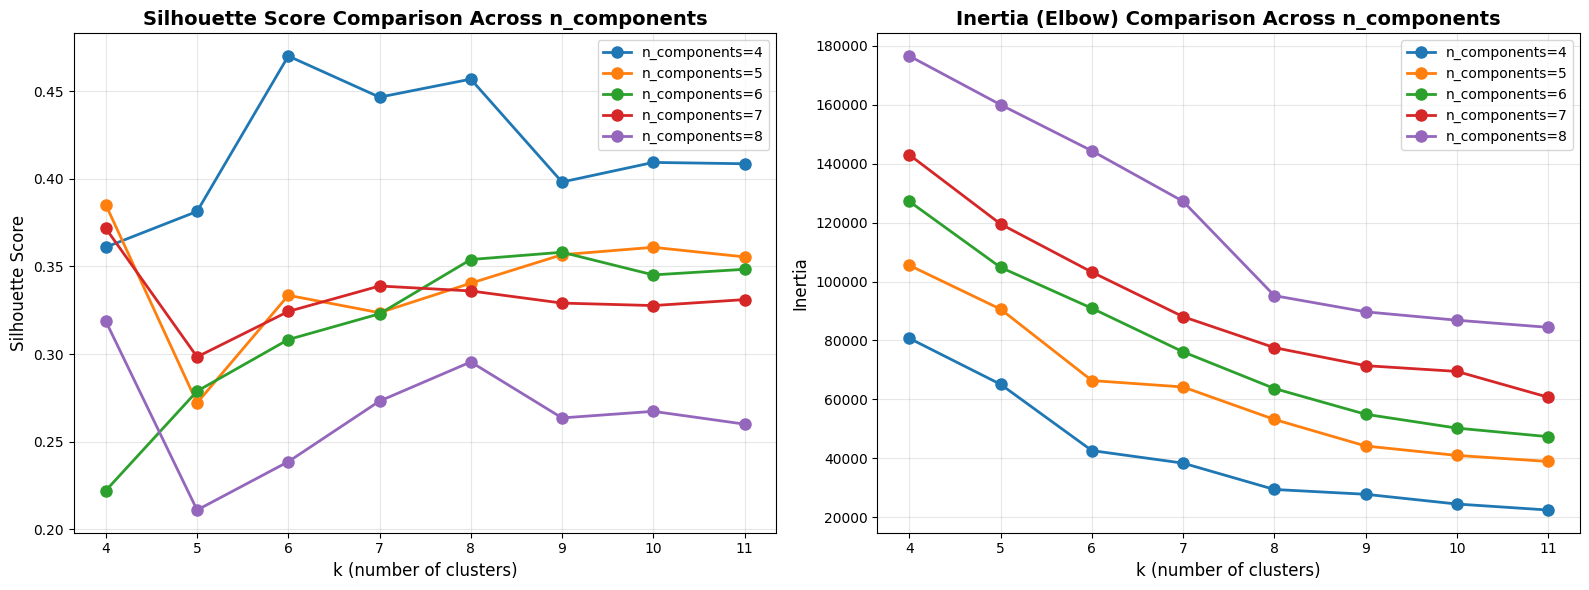

In [99]:
for n_comp in n_components_list:
    results = all_results[n_comp]
# Overlay comparison plot: Silhouette scores across all n_components
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Silhouette scores comparison
for n_comp in n_components_list:
    results = all_results[n_comp]
    ax1.plot(results['k_list'], results['silhouette'], 
              marker='o', linewidth=2, markersize=8, 
              label=f'n_components={n_comp}')

ax1.set_title('Silhouette Score Comparison Across n_components', fontsize=14, fontweight='bold')
ax1.set_xlabel('k (number of clusters)', fontsize=12)
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: Inertia comparison
for n_comp in n_components_list:
    results = all_results[n_comp]
    ax2.plot(results['k_list'], results['inertia'], 
             marker='o', linewidth=2, markersize=8, 
             label=f'n_components={n_comp}')

ax2.set_title('Inertia (Elbow) Comparison Across n_components', fontsize=14, fontweight='bold')
ax2.set_xlabel('k (number of clusters)', fontsize=12)
ax2.set_ylabel('Inertia', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [100]:
# Final FAMD embedding for export; cluster column on df comes from imported labels
n_components_final = 4
famd = prince.FAMD(
    n_components=4, 
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=42,
    engine="sklearn",
    handle_unknown="error"
)
famd = famd.fit(df_famd)
X_famd = famd.row_coordinates(df_famd)

print("FAMD scores shape:", X_famd.shape)
before_famd = "../Clustering/VersionA_Business_AfterFAMD.csv"
X_famd.to_csv(before_famd, index=False)

# Get the FAMD transformed data
X_final = all_results[n_components_final]['X']


FAMD scores shape: (8311, 4)


In [101]:
famd.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,8.021,6.63%,6.63%
1,4.604,3.80%,10.43%
2,3.932,3.25%,13.68%
3,3.505,2.90%,16.58%


In [102]:
famd.column_contributions_.style.format('{:.2%}')

component,0,1,2,3
variable,,,,
sales_cents,0.02%,0.06%,0.01%,0.03%
account_age,0.04%,0.18%,0.02%,0.02%
birth_business_age,0.06%,0.20%,0.03%,0.02%
total_transaction_count,3.81%,13.42%,0.09%,0.02%
transaction_count_Card,8.86%,1.08%,0.04%,0.03%
transaction_count_Cheque,0.23%,3.95%,0.01%,0.01%
transaction_count_EFT,0.70%,13.41%,0.06%,0.02%
transaction_count_EMT,0.23%,0.69%,0.00%,0.01%
debit_transaction_count,6.66%,7.41%,0.09%,0.02%


## Imported Cluster Labels

Cluster assignments come from `business_kmeans_estimation_labels` from Kmeans clustering in Rmarkdown. Please follow the following operations:
1. Run the code above. The elbow and silhouette score assists k selection.
2. Run the Rmarkdown with the created csv from above code.
3. Run the code below for visualization.

In [103]:

KMEANS_LABELS_CSV = "../Clustering/business_kmeans_estimation_labels.csv"


def _load_kmeans_labels(path):
    df_lab = pd.read_csv(path, sep=None, engine="python")
    df_lab.columns = df_lab.columns.str.strip()
    for col in ("customer_id", "cluster_raw", "cluster_num"):
        if col not in df_lab.columns:
            raise ValueError(f"Expected column {col!r} in {path}, got {list(df_lab.columns)}")
    return df_lab

kmeans_labels_df = _load_kmeans_labels(KMEANS_LABELS_CSV)
business_mask = df_full["kyc_type"].str.lower() == "business"
cust = df_full.loc[business_mask, "customer_id"].reset_index(drop=True)
if len(cust) != len(df):
    raise ValueError(
        f"customer_id alignment mismatch: {len(cust)} ids vs df rows {len(df)}"
    )
m = cust.to_frame().merge(kmeans_labels_df, on="customer_id", how="left")
if m["cluster_raw"].isna().any():
    raise ValueError(
        f"{m['cluster_raw'].isna().sum()} rows missing labels in {KMEANS_LABELS_CSV}"
    )
df["cluster"] = m["cluster_raw"].values
k_final = int(m["cluster_num"].nunique())

print(f"Using n_components={n_components_final} with k={k_final} (cluster column from imported labels)")
print(f"Data shape: {X_final.shape}")

Using n_components=4 with k=6 (cluster column from imported labels)
Data shape: (8311, 4)


In [104]:
# Restore customer_id from df_full for merging
# Match business customers from df_full using the filtered indices
business_mask = df_full['kyc_type'].str.lower() == 'business'
df_full_business = df_full[business_mask].copy().reset_index(drop=True)
df_with_id = df.reset_index(drop=True).copy()
df_with_id['customer_id'] = df_full_business['customer_id'].values

# Same row order as master_customer_df (customer_id ascending)
df_with_id = df_with_id.sort_values('customer_id', ascending=True).reset_index(drop=True)

# Save cluster results to separate business CSV (for reference)
output_path_business = "../Clustering/Kmeans_Business.csv"
df_with_id.to_csv(output_path_business, index=False)
print(f"Business cluster results saved to {output_path_business}")
print(f"Total rows saved: {len(df_with_id)}")
print(f"Columns saved: {len(df_with_id.columns)}")

# Save to combined Kmeans_Seperate.csv
output_path_separate = "../Clustering/Kmeans_Seperate.csv"

# Create dataframe with customer_id and cluster label
business_clusters = df_with_id[['customer_id', 'cluster']].copy()

# Check if Kmeans_Seperate.csv exists
if Path(output_path_separate).exists():
    # Read existing file and merge business cluster labels
    df_separate = pd.read_csv(output_path_separate)
    print(f"\nFound existing {output_path_separate} with {len(df_separate)} rows")
    
    # Merge business cluster labels
    if 'cluster' in df_separate.columns:
        # Update existing cluster column for business customers
        df_separate = df_separate.merge(business_clusters, on='customer_id', how='left', suffixes=('', '_new'))
        df_separate['cluster'] = df_separate['cluster_new'].fillna(df_separate['cluster'])
        df_separate = df_separate.drop(columns=['cluster_new'])
    else:
        # Add cluster column
        df_separate = df_separate.merge(business_clusters, on='customer_id', how='left')
else:
    # Create new file from full dataframe with business cluster labels
    df_separate = df_full[['customer_id']].copy()
    df_separate = df_separate.merge(business_clusters, on='customer_id', how='left')
    print(f"\nCreating new {output_path_separate}")

# Same row order as master_customer_df (sort_values customer_id ascending)
df_separate = df_separate.sort_values('customer_id', ascending=True).reset_index(drop=True)

# Save to Kmeans_Seperate.csv
df_separate.to_csv(output_path_separate, index=False)
print(f"  Total rows: {len(df_separate)}")
print(f"  Customers without cluster labels: {df_separate['cluster'].isna().sum()}")

Business cluster results saved to ../Clustering/Kmeans_Business.csv
Total rows saved: 8311
Columns saved: 31

Found existing ../Clustering/Kmeans_Seperate.csv with 61410 rows
  Total rows: 61410
  Customers without cluster labels: 0


## Result Analysis & Visualizations

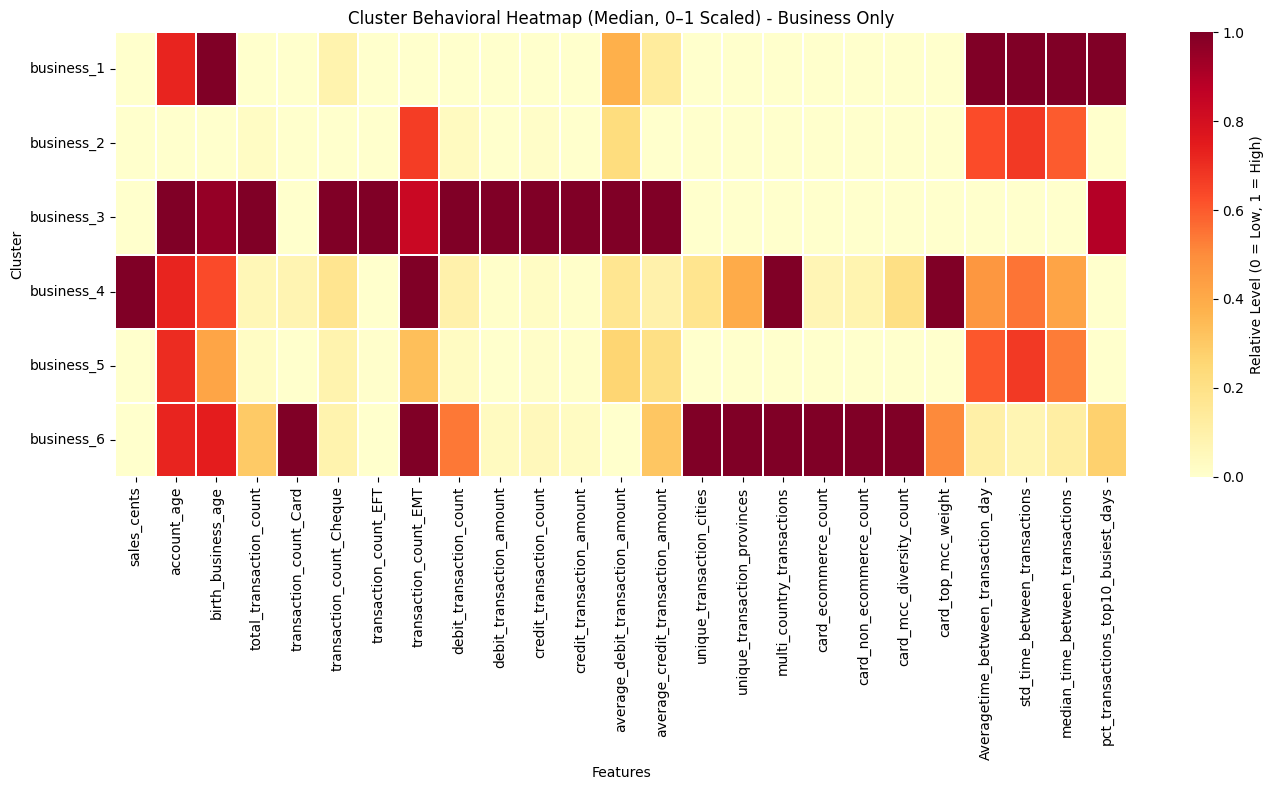

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include="number").columns.drop("cluster", errors="ignore")

# Cluster medians
cluster_medians = df.groupby("cluster")[num_cols].median()

# Min–max scale per feature (column-wise)
cluster_medians_01 = (
    cluster_medians - cluster_medians.min()
) / (cluster_medians.max() - cluster_medians.min())

plt.figure(figsize=(14, 8))
sns.heatmap(
    cluster_medians_01,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Relative Level (0 = Low, 1 = High)"}
)

plt.title("Cluster Behavioral Heatmap (Median, 0–1 Scaled) - Business Only")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [106]:
# Categorize features by score ranges for each cluster
print("=" * 80)
print("FEATURE CATEGORIZATION BY CLUSTER (Numerical Heatmap Scores)")
print("=" * 80)
print()

for cluster in sorted(cluster_medians_01.index):
    cluster_scores = cluster_medians_01.loc[cluster]
    
    # High scores: 0.65 to 1.0
    high_features = cluster_scores[(cluster_scores >= 0.65) & (cluster_scores <= 1.0)].sort_values(ascending=False)
    
    # Moderate scores: 0.35 to 0.65
    moderate_features = cluster_scores[(cluster_scores >= 0.35) & (cluster_scores < 0.65)].sort_values(ascending=False)
    
    high_list = list(high_features.index) if len(high_features) > 0 else []
    moderate_list = list(moderate_features.index) if len(moderate_features) > 0 else []
    
    print(f"cluster {cluster}: High: {high_list} Moderate: {moderate_list}")


FEATURE CATEGORIZATION BY CLUSTER (Numerical Heatmap Scores)

cluster business_1: High: ['birth_business_age', 'Averagetime_between_transaction_day', 'std_time_between_transactions', 'median_time_between_transactions', 'pct_transactions_top10_busiest_days', 'account_age'] Moderate: ['average_debit_transaction_amount']
cluster business_2: High: ['std_time_between_transactions', 'transaction_count_EMT'] Moderate: ['Averagetime_between_transaction_day', 'median_time_between_transactions']
cluster business_3: High: ['account_age', 'total_transaction_count', 'transaction_count_Cheque', 'transaction_count_EFT', 'debit_transaction_count', 'debit_transaction_amount', 'credit_transaction_count', 'credit_transaction_amount', 'average_debit_transaction_amount', 'average_credit_transaction_amount', 'birth_business_age', 'pct_transactions_top10_busiest_days', 'transaction_count_EMT'] Moderate: []
cluster business_4: High: ['sales_cents', 'transaction_count_EMT', 'multi_country_transactions', 'card_

In [ ]:
cluster_sizes = df["cluster"].value_counts().sort_index()

print("Cluster sizes - Business Only")
print(cluster_sizes.rename("n_customers").to_string())
print(f"Total customers: {int(cluster_sizes.sum())}")

Cluster sizes - Business Only
cluster
business_1    4004
business_2     618
business_3     196
business_4    2687
business_5     108
business_6     698
Total customers: 8311


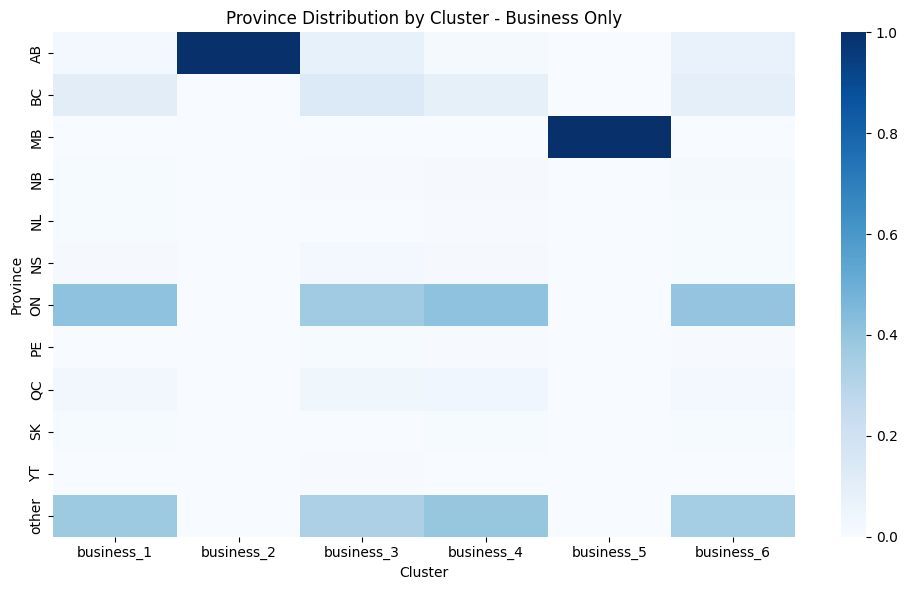

In [108]:
province_dist = pd.crosstab(
    df["province"],
    df["cluster"],
    normalize="columns"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    province_dist,
    cmap="Blues"
)
plt.title("Province Distribution by Cluster - Business Only")
plt.xlabel("Cluster")
plt.ylabel("Province")
plt.tight_layout()
plt.show()

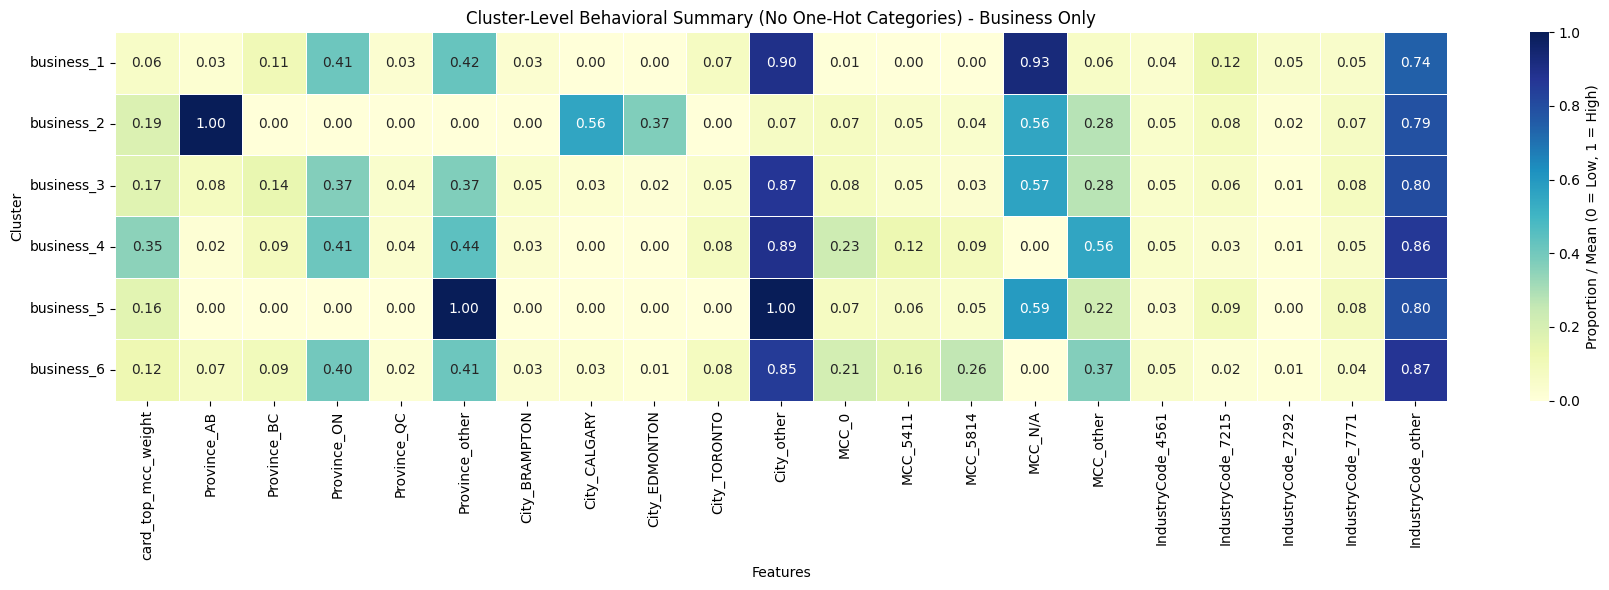

In [109]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Helper: categorical proportions
def categorical_cluster_proportions(df, cluster_col, cat_col, top_n=5):
    """
    Rows = clusters
    Columns = top-N categories (+ other)
    Values = proportion within cluster
    """
    # Convert to string if categorical to avoid type errors
    col_series = df[cat_col].astype(str) if df[cat_col].dtype.name == 'category' else df[cat_col]
    
    top_vals = col_series.value_counts().head(top_n).index
    collapsed = col_series.where(col_series.isin(top_vals), "other")

    return pd.crosstab(
        df[cluster_col],
        collapsed,
        normalize="index"
    )

# Build heatmap dataframe
heatmap_df = pd.DataFrame(
    index=sorted(df["cluster"].unique())
)

# Numeric dominance / indicator-style features
heatmap_df["card_top_mcc_weight"] = (
    df.groupby("cluster")["card_top_mcc_weight"].mean()
)

# Categorical summaries (NO indicators)

# Province (top 5)
prov_prop = categorical_cluster_proportions(df, "cluster", "province", top_n=5)
prov_prop.columns = [f"Province_{c}" for c in prov_prop.columns]
heatmap_df = heatmap_df.join(prov_prop)

# City (top 5)
city_prop = categorical_cluster_proportions(df, "cluster", "city", top_n=5)
city_prop.columns = [f"City_{c}" for c in city_prop.columns]
heatmap_df = heatmap_df.join(city_prop)

# Top MCC (top 5)
mcc_prop = categorical_cluster_proportions(df, "cluster", "card_top_mcc", top_n=5)
mcc_prop.columns = [f"MCC_{c}" for c in mcc_prop.columns]
heatmap_df = heatmap_df.join(mcc_prop)

# Industry code (top 5)
industry_code_prop = categorical_cluster_proportions(df, "cluster", "industry_code", top_n=5)
industry_code_prop.columns = [f"IndustryCode_{c}" for c in industry_code_prop.columns]
heatmap_df = heatmap_df.join(industry_code_prop)

# Plot heatmap
plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Proportion / Mean (0 = Low, 1 = High)"}
)

plt.title("Cluster-Level Behavioral Summary (No One-Hot Categories) - Business Only")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [110]:
# Silhouette + Elbow score from imported cluster_num
import numpy as np
from sklearn.metrics import silhouette_score

# Use the same feature space used for clustering earlier
if "X_famd" in globals():
    X_eval = np.asarray(X_famd, dtype=np.float64)
elif "all_results" in globals() and len(all_results) > 0:
    best_key = sorted(all_results.keys())[-1]
    X_eval = np.asarray(all_results[best_key]["X"], dtype=np.float64)
elif "X" in globals():
    X_eval = np.asarray(X, dtype=np.float64)
else:
    X_eval = np.asarray(df.select_dtypes(include=[np.number]).drop(columns=["cluster", "cluster_num"], errors="ignore"), dtype=np.float64)

# Labels imported from CSV
y = kmeans_labels_df["cluster_num"].astype(int).to_numpy()

if X_eval.shape[0] != y.shape[0]:
    raise ValueError(f"Row mismatch: X has {X_eval.shape[0]} rows but labels have {y.shape[0]} rows.")

sil = silhouette_score(X_eval, y)

# Elbow score = within-cluster sum of squares using imported labels
elbow_score = 0.0
for lab in np.unique(y):
    pts = X_eval[y == lab]
    centroid = pts.mean(axis=0)
    elbow_score += ((pts - centroid) ** 2).sum()

print(f"Rows evaluated: {len(y):,}")
print(f"k (from cluster_num): {len(np.unique(y))}")
print(f"Silhouette score: {sil:.6f}")
print(f"Elbow score: {elbow_score:,.2f}")


Rows evaluated: 8,311
k (from cluster_num): 6
Silhouette score: 0.470222
Elbow score: 42,632.62
